In [ ]:
!pip install river joblib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


100000
Epoch 0, Loss: 2.1436
Epoch 10, Loss: 2.0658
Epoch 20, Loss: 1.9875
Epoch 30, Loss: 1.8939
Epoch 40, Loss: 1.7572
Epoch 50, Loss: 1.5035
Epoch 60, Loss: 1.0354
Epoch 70, Loss: 0.6067
Epoch 80, Loss: 0.4603
Epoch 90, Loss: 0.4241
Epoch 100, Loss: 0.4035
Epoch 110, Loss: 0.3993
Epoch 120, Loss: 0.3979
Epoch 130, Loss: 0.3968
Epoch 140, Loss: 0.3959
Epoch 150, Loss: 0.3951
Epoch 160, Loss: 0.3941
Epoch 170, Loss: 0.3929
Epoch 180, Loss: 0.3913
Epoch 190, Loss: 0.3891
Epoch 200, Loss: 0.3860
Epoch 210, Loss: 0.3823
Epoch 220, Loss: 0.3779
Epoch 230, Loss: 0.3725
Epoch 240, Loss: 0.3660
Epoch 250, Loss: 0.3591
Epoch 260, Loss: 0.3528
Epoch 270, Loss: 0.3475
Epoch 280, Loss: 0.3434
Epoch 290, Loss: 0.3402
Epoch 300, Loss: 0.3375
Epoch 310, Loss: 0.3353
Epoch 320, Loss: 0.3332
Epoch 330, Loss: 0.3313
Epoch 340, Loss: 0.3294
Epoch 350, Loss: 0.3276
Epoch 360, Loss: 0.3257
Epoch 370, Loss: 0.3238
Epoch 380, Loss: 0.3218
Epoch 390, Loss: 0.3197
Epoch 400, Loss: 0.3172
Epoch 410, Loss: 0.3

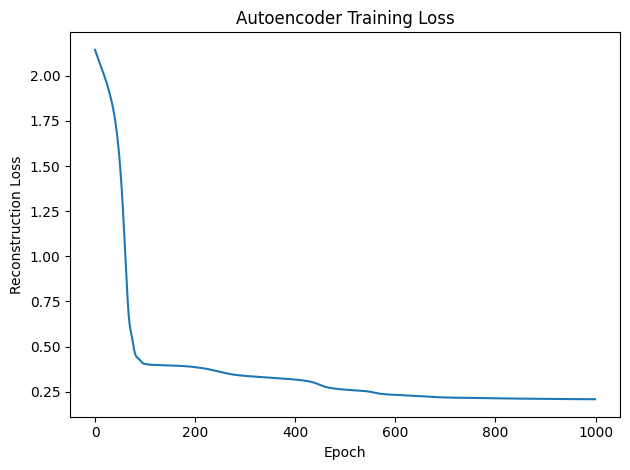

Offline bootstrap complete.


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import random
from river import cluster as river_cluster
from river import utils as river_utils
from river import drift
import joblib
import os

DATA_PATH = "data/Investor_Data_Syn.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape[0])

Q_dist = {
    "Q1": (["A", "B", "C", "D"], [0.4, 0.3, 0.2, 0.1]),
    "Q2": (["A", "B", "C", "D"], [0.1, 0.2, 0.4, 0.3]),
    "Q3": (["A", "B", "C"], [0.3, 0.5, 0.2]),
    "Q4": (["A", "B", "C"], [0.2, 0.5, 0.3]),
    "Q5": (["A", "B", "C", "D"], [0.25, 0.25, 0.3, 0.2]),
    "Q6": (["A", "B", "C"], [0.4, 0.4, 0.2]),
}
Q_mappings = {q: {ans: len(answers) - i for i, ans in enumerate(answers)} for q, (answers, _) in Q_dist.items()}
for q in Q_dist:
    df[q] = df[q].map(Q_mappings[q])

cat_cols = ["gender", "main_occupation", "marital_status", "form_type", "filing_timeliness"]
num_cols = ["age", "dependents", "gross_income", "tax_paid"]

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
df_cat_encoded = pd.DataFrame(cat_encoded, columns=cat_feature_names, index=df.index)

scaler = StandardScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols, index=df.index)

df_processed = pd.concat([df_num_scaled, df_cat_encoded, df[list(Q_dist.keys())]], axis=1)
feature_columns = df_processed.columns.tolist()

X_input = torch.tensor(df_processed.values, dtype=torch.float32)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

def _ensure_centers(model):
    if not hasattr(model, "centers"):
        model.centers = {}
    return model.centers

def kmeans_predict_manual(model, features):
    centers = _ensure_centers(model)
    if not centers:
        return None
    best_cid, best_dist = None, float("inf")
    keys = list(features.keys())
    for cid, center in centers.items():
        deltas = [features[k] - center.get(k, 0.0) for k in keys]
        dist = float(np.linalg.norm(deltas))
        if dist < best_dist:
            best_cid, best_dist = cid, dist
    return best_cid

def kmeans_learn_manual(model, features, lr=0.2):
    centers = _ensure_centers(model)
    cid = kmeans_predict_manual(model, features)
    if cid is None:
        new_id = len(centers)
        if new_id < model.n_clusters:
            centers[new_id] = features.copy()
        else:
            fallback = model.n_clusters - 1
            centers.setdefault(fallback, features.copy())
        return model
    center = centers[cid]
    for k, v in features.items():
        prev = center.get(k, 0.0)
        center[k] = prev + lr * (v - prev)
    centers[cid] = center
    model.centers = centers
    return model

input_dim = X_input.shape[1]
latent_dim = 5
ae = Autoencoder(input_dim, latent_dim)
optimizer = optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 1000
losses = []
ae.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    recon = ae(X_input)
    loss = loss_fn(recon, X_input)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.tight_layout()
plt.show()

ae.eval()
with torch.no_grad():
    latent_features = ae.encoder(X_input).cpu().numpy()

sk_kmeans = KMeans(n_clusters=3, init="k-means++", random_state=seed, n_init=30)
cluster_ids = sk_kmeans.fit_predict(latent_features)
centroids = sk_kmeans.cluster_centers_

centroid_means = centroids.mean(axis=1)
sorted_clusters = np.argsort(centroid_means)
cluster_to_label = dict(zip(sorted_clusters, ["Conservative", "Moderate", "Aggressive"]))

risk_ranges = {
    "Conservative": {"base": 10, "min": 0, "max": 20},
    "Moderate": {"base": 50, "min": 35, "max": 65},
    "Aggressive": {"base": 85, "min": 70, "max": 100},
}

cluster_distance_stats = {c: {"min": np.inf, "max": 0.0} for c in range(sk_kmeans.n_clusters)}
offline_distances = np.linalg.norm(latent_features - centroids[cluster_ids], axis=1)
for dist, cid in zip(offline_distances, cluster_ids):
    stats = cluster_distance_stats[cid]
    stats["min"] = min(stats["min"], dist)
    stats["max"] = max(stats["max"], dist)

for stats in cluster_distance_stats.values():
    if not np.isfinite(stats["min"]):
        stats["min"] = 0.0
    if stats["max"] - stats["min"] < 1e-6:
        stats["max"] = stats["min"] + 1e-6

distances_norm = np.array([
    (dist - cluster_distance_stats[cid]["min"]) / (cluster_distance_stats[cid]["max"] - cluster_distance_stats[cid]["min"])
    for dist, cid in zip(offline_distances, cluster_ids)
])
risk_categories = [cluster_to_label[c] for c in cluster_ids]
risk_scores = np.array([
    risk_ranges[risk_categories[i]]["max"] - distances_norm[i] * (risk_ranges[risk_categories[i]]["max"] - risk_ranges[risk_categories[i]]["min"])
    for i in range(len(cluster_ids))
])

initial_centers = [{f"f{i}": float(center[i]) for i in range(latent_dim)} for center in centroids]
river_kmeans = river_cluster.KMeans(
    n_clusters=3,
    halflife=0.5,
    sigma=1.0,
    seed=seed,
)
river_kmeans.centers = {idx: center.copy() for idx, center in enumerate(initial_centers)}
for latent_vec in latent_features:
    latent_dict = {f"f{i}": float(val) for i, val in enumerate(latent_vec)}
    river_kmeans = kmeans_learn_manual(river_kmeans, latent_dict)

print("Offline bootstrap complete.")

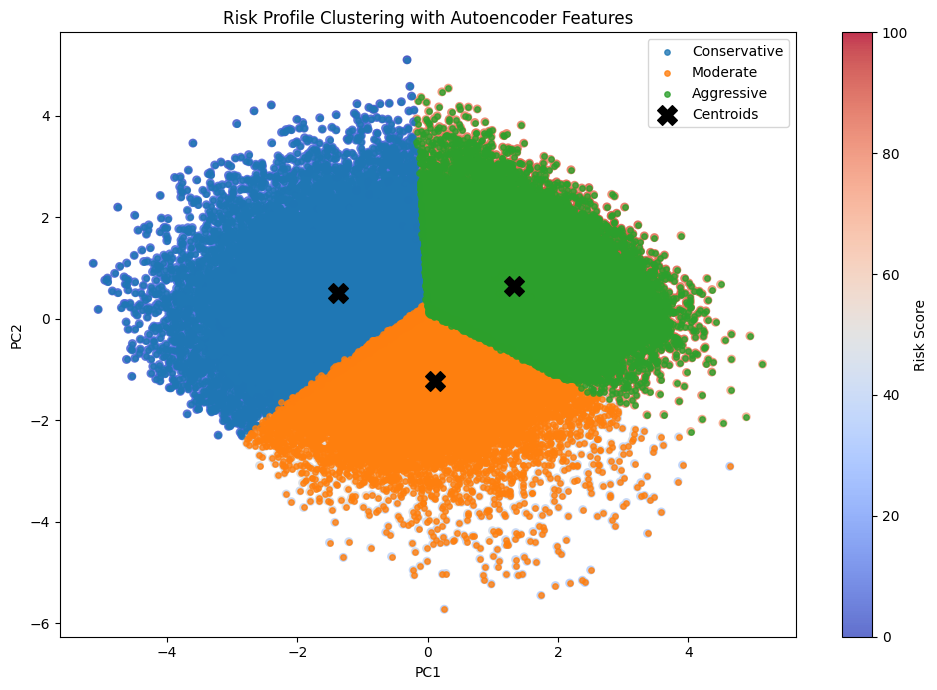

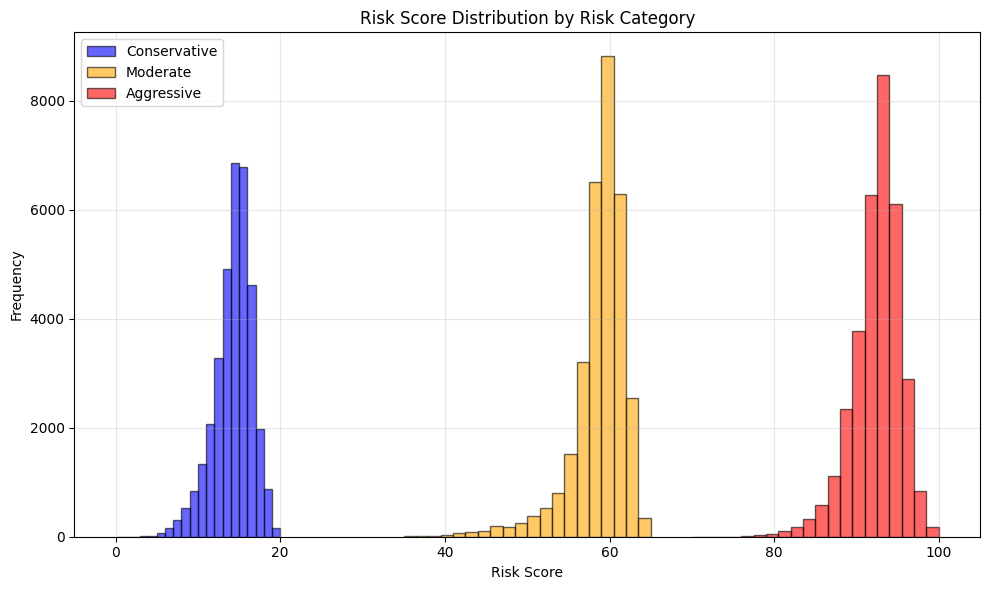

<Figure size 800x500 with 0 Axes>

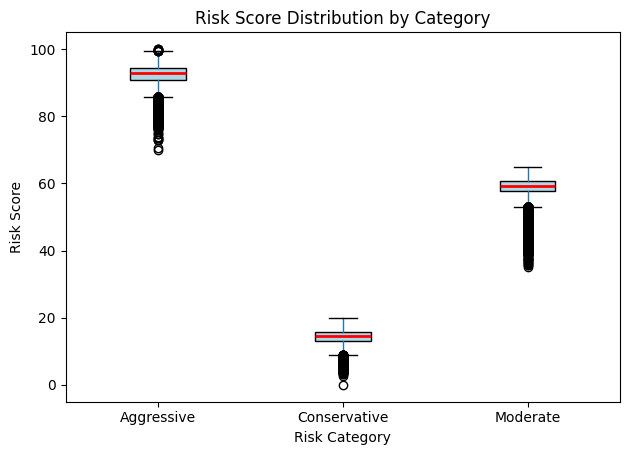

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(latent_features)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=risk_scores, cmap="coolwarm", s=30, alpha=0.8)
for label in ["Conservative", "Moderate", "Aggressive"]:
    mask = np.array(risk_categories) == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=label, s=15, alpha=0.8)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=200, c="black", label="Centroids")
plt.title("Risk Profile Clustering with Autoencoder Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Risk Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for label, color in zip(["Conservative", "Moderate", "Aggressive"], ["blue", "orange", "red"]):
    subset = np.array(risk_scores)[np.array(risk_categories) == label]
    plt.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor="black")
plt.title("Risk Score Distribution by Risk Category")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
pd.DataFrame({"Risk_Category": risk_categories, "Risk_Score": risk_scores}).boxplot(
    column="Risk_Score",
    by="Risk_Category",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="red", linewidth=2),
)
plt.title("Risk Score Distribution by Category")
plt.suptitle("")
plt.xlabel("Risk Category")
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()

In [ ]:
class OnlineRiskScorer:
    def __init__(
        self,
        autoencoder,
        river_kmeans,
        scaler,
        ohe,
        q_mappings,
        num_cols,
        cat_cols,
        feature_columns,
        risk_ranges,
        cluster_to_label,
        cluster_distance_stats,
    ):
        self.autoencoder = autoencoder
        self.kmeans = river_kmeans
        self.scaler = scaler
        self.ohe = ohe
        self.q_mappings = q_mappings
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.feature_columns = feature_columns
        self.risk_ranges = risk_ranges
        self.cluster_to_label = cluster_to_label
        self.cluster_distance_stats = cluster_distance_stats
        self.update_cnt = 0
        self.latent_dim = list(river_kmeans.centers.values())[0].__len__()
        self.drift_detector = drift.ADWIN()

    def _latent_to_dict(self, latent_vec):
        return {f"f{i}": float(val) for i, val in enumerate(latent_vec)}

    def _center_array(self, cluster_id):
        centers = _ensure_centers(self.kmeans)
        center_dict = centers.get(cluster_id, {})
        return np.array([center_dict.get(f"f{i}", 0.0) for i in range(self.latent_dim)])

    def _preprocess(self, sample_dict):
        df_sample = pd.DataFrame([sample_dict])
        for q in self.q_mappings:
            df_sample[q] = df_sample[q].map(self.q_mappings[q])
        cat_transformed = self.ohe.transform(df_sample[self.cat_cols])
        df_cat = pd.DataFrame(cat_transformed, columns=self.ohe.get_feature_names_out(self.cat_cols))
        for col in self.feature_columns:
            if col not in df_cat.columns and col not in self.num_cols and col not in self.q_mappings:
                df_cat[col] = 0.0
        df_cat = df_cat.reindex(columns=[c for c in self.feature_columns if c not in self.num_cols and c not in self.q_mappings], fill_value=0.0)
        df_num = pd.DataFrame(self.scaler.transform(df_sample[self.num_cols]), columns=self.num_cols)
        df_ord = df_sample[list(self.q_mappings.keys())]
        df_processed = pd.concat([df_num, df_cat, df_ord], axis=1)
        df_processed = df_processed[self.feature_columns]
        return torch.tensor(df_processed.values, dtype=torch.float32)

    def predict_and_update(self, sample_dict, update=True):
        x_tensor = self._preprocess(sample_dict)
        self.autoencoder.eval()
        with torch.no_grad():
            latent_vec = self.autoencoder.encoder(x_tensor).cpu().numpy()[0]
            reconstruction=self.autoencoder(x_tensor)

        recon_error=float(torch.mean((reconstruction-x_tensor)**2).item())
        drift_alert = self.drift_detector.update(recon_error)
        latent_dict = self._latent_to_dict(latent_vec)
        cluster_id = kmeans_predict_manual(self.kmeans, latent_dict)
        if cluster_id is None:
            self.kmeans = kmeans_learn_manual(self.kmeans, latent_dict, lr=0.2)
            cluster_id = kmeans_predict_manual(self.kmeans, latent_dict)
        centroid_vec = self._center_array(cluster_id)
        dist = float(np.linalg.norm(latent_vec - centroid_vec))
        stats = self.cluster_distance_stats[cluster_id]
        stats["min"] = min(stats["min"], dist)
        stats["max"] = max(stats["max"], dist + 1e-6)
        denom = stats["max"] - stats["min"]
        dist_norm = (dist - stats["min"]) / denom if denom > 1e-8 else 0.0
        risk_label = self.cluster_to_label[cluster_id]
        r = self.risk_ranges[risk_label]
        risk_score = r["max"] - dist_norm * (r["max"] - r["min"])
        if update:
            self.kmeans = kmeans_learn_manual(self.kmeans, latent_dict, lr=0.2)
            self.update_cnt+=1
        return {
            "cluster_id": cluster_id,
            "risk_label": risk_label,
            "risk_score": float(risk_score),
            "distance": dist,
            "dist_norm": float(dist_norm),
            "reconstruction_error": recon_error,
            "drift_detected": bool(drift_alert),
        }

    def save(self, directory):
        os.makedirs(directory, exist_ok=True)
        torch.save(self.autoencoder.state_dict(), os.path.join(directory, "autoencoder.pt"))
        joblib.dump(
            {
                "scaler": self.scaler,
                "ohe": self.ohe,
                "q_mappings": self.q_mappings,
                "num_cols": self.num_cols,
                "cat_cols": self.cat_cols,
                "feature_columns": self.feature_columns,
                "risk_ranges": self.risk_ranges,
                "cluster_to_label": self.cluster_to_label,
                "cluster_distance_stats": self.cluster_distance_stats,
            },
            os.path.join(directory, "preprocessors.joblib"),
        )
        river_utils.estimator.dump(self.kmeans, os.path.join(directory, "river_kmeans.pkl"))

    @staticmethod
    def load(directory, autoencoder_class, input_dim, latent_dim):
        autoencoder = autoencoder_class(input_dim, latent_dim)
        autoencoder.load_state_dict(torch.load(os.path.join(directory, "autoencoder.pt"), map_location="cpu"))
        bundle = joblib.load(os.path.join(directory, "preprocessors.joblib"))
        kmeans = river_utils.estimator.load(os.path.join(directory, "river_kmeans.pkl"))
        return OnlineRiskScorer(
            autoencoder=autoencoder,
            river_kmeans=kmeans,
            scaler=bundle["scaler"],
            ohe=bundle["ohe"],
            q_mappings=bundle["q_mappings"],
            num_cols=bundle["num_cols"],
            cat_cols=bundle["cat_cols"],
            feature_columns=bundle["feature_columns"],
            risk_ranges=bundle["risk_ranges"],
            cluster_to_label=bundle["cluster_to_label"],
            cluster_distance_stats=bundle["cluster_distance_stats"],
        )

online_scorer = OnlineRiskScorer(
    autoencoder=ae,
    river_kmeans=river_kmeans,
    scaler=scaler,
    ohe=ohe,
    q_mappings=Q_mappings,
    num_cols=num_cols,
    cat_cols=cat_cols,
    feature_columns=feature_columns,
    risk_ranges=risk_ranges,
    cluster_to_label=cluster_to_label,
    cluster_distance_stats=cluster_distance_stats,
)
def log_online_updates():
    print(f"Online updates so far: {online_scorer.update_cnt}")

def log_drift_state():
    detector = online_scorer.drift_detector
    print(f"Drift detected: {detector.drift_detected}")
    print(f"ADWIN width: {detector.width}")

print("OnlineRiskScorer ready.")

OnlineRiskScorer ready.


In [5]:
# incoming_user = {
#     "age": 50,
#     "dependents": 4,
#     "gross_income": 3150000,
#     "tax_paid": 587600,
#     "gender": "Male",
#     "main_occupation": "Salaried",
#     "marital_status": "Married",
#     "form_type": "ITR-2",
#     "filing_timeliness": "Belated",
#     "Q1": "A",
#     "Q2": "C",
#     "Q3": "B",
#     "Q4": "B",
#     "Q5": "C",
#     "Q6": "A",
# }

incoming_user={
    "age": 37,
        "gender": "Female",
        "main_occupation": "Professional",
        "marital_status": "Married",
        "dependents": 1,
        "gross_income": 1980000,
        "tax_paid": 224640,
        "form_type": "ITR-3",
        "filing_timeliness": "Revised",
        "Q1": "B",
        "Q2": "C",
        "Q3": "B",
        "Q4": "C",
        "Q5": "C",
        "Q6": "B",
}

result = online_scorer.predict_and_update(incoming_user, update=True)
log_online_updates()
log_drift_state()
print(f"Predicted Risk Category: {result['risk_label']}")
print(f"Predicted Risk Score: {result['risk_score']:.2f}")
print(f"Cluster ID: {result['cluster_id']} | Distance: {result['distance']:.4f}")

Online updates so far: 1
Drift detected: False
ADWIN width: 1.0
Predicted Risk Category: Moderate
Predicted Risk Score: 63.69
Cluster ID: 2 | Distance: 0.4313
